In [12]:
from pathlib import Path
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import pipeline
import random
from scipy.stats import spearmanr
import statistics
import itertools

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [2]:
gpath = Path('data/undir_trials/thresholded_networks/0_network.txt')
G = pipeline.load(gpath)

Nodes: 115355
Edges: 1015920


# POI Dependency Network — Descriptive Analysis

Goal: characterise the raw network structure to inform link prediction strategy — e.g. whether the graph is scale-free, how densely clustered it is, whether spatial proximity drives edges, and which POI types dominate.

## 1. Basic Topology

In [7]:
def characterize(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)

    degrees = np.array([d for _, d in G.degree()])
    avg_deg    = degrees.mean()
    max_deg    = int(degrees.max())
    median_deg = int(np.median(degrees))

    ccs = sorted(nx.connected_components(G), key=len, reverse=True)
    n_ccs    = len(ccs)
    lcc_size = len(ccs[0])
    lcc_frac = lcc_size / n
    avg_clust    = nx.average_clustering(G)
    transitivity = nx.transitivity(G)

    # approximate diameter via double-sweep BFS
    def approx_diameter(H):
        src = next(iter(H.nodes()))
        lengths1 = nx.single_source_shortest_path_length(H, src)
        far1 = max(lengths1, key=lengths1.get)
        lengths2 = nx.single_source_shortest_path_length(H, far1)
        far2 = max(lengths2, key=lengths2.get)
        return lengths2[far2]

    # approximate aspl
    def estimate_aspl(G, sample_size=100):
        nodes = list(G.nodes())
        if len(nodes) <= sample_size:
            return nx.average_shortest_path_length(G)
        
        # Pick random source nodes
        sources = random.sample(nodes, sample_size)
        lengths = []
        
        for source in sources:
            # Get distances from source to all other nodes
            path_dict = nx.single_source_shortest_path_length(G, source)
            lengths.extend(path_dict.values())
            
        return np.mean(lengths)

    lcc_sub     = G.subgraph(ccs[0])
    diam_approx = approx_diameter(lcc_sub)
    aspl = estimate_aspl(lcc_sub)

    # modularity
    partition = nx.community.louvain_communities(lcc_sub)
    modularity = nx.community.modularity(lcc_sub, partition)

    print('=' * 50)
    print('  BASIC GRAPH STATISTICS')
    print('=' * 50)
    print(f'  Nodes                 : {n:>12,}')
    print(f'  Edges                 : {m:>12,}')
    print(f'  Density               : {density:>12.6f}')
    print(f'  Avg degree            : {avg_deg:>12.2f}')
    print(f'  Max degree            : {max_deg:>12,}')
    print(f'  Median degree         : {median_deg:>12,}')
    print(f'  Connected components  : {n_ccs:>12,}')
    print(f'  LCC (nodes)           : {lcc_size:>12,}  ({lcc_frac:.1%})')
    print(f'  LCC density           : {nx.density(lcc_sub):>12.6f}')
    print(f'  Approx diameter (LCC) : {diam_approx:>12,}')
    print(f'  Approx ASPL           : {aspl:>12.4f}')
    print(f'  Avg clustering coef   : {avg_clust:>12.4f}')
    print(f'  Highest modularity    : {modularity:>12.4f}')
    print(f'  Transitivity          : {transitivity:>12.4f}')
    print('=' * 50)

print('ORIGINAL:\n')
characterize(G)

# --- null model comparison ---

print('NULL:\n')
deg_seq = [d for n, d in G.degree()]
null_model_multi = nx.configuration_model(deg_seq)
# Convert to simple graph to allow clustering metrics
null_model = nx.Graph(null_model_multi) 
null_model.remove_edges_from(nx.selfloop_edges(null_model)) # Optional: clean up loops
characterize(null_model)

ORIGINAL:

  BASIC GRAPH STATISTICS
  Nodes                 :      115,355
  Edges                 :    1,015,920
  Density               :     0.000153
  Avg degree            :        17.61
  Max degree            :           83
  Median degree         :           17
  Connected components  :           38
  LCC (nodes)           :      115,270  (99.9%)
  LCC density           :     0.000153
  Approx diameter (LCC) :           13
  Approx ASPL           :       4.8226
  Avg clustering coef   :       0.0488
  Highest modularity    :       0.7011
  Transitivity          :       0.0447
NULL:

  BASIC GRAPH STATISTICS
  Nodes                 :      115,355
  Edges                 :    1,015,802
  Density               :     0.000153
  Avg degree            :        17.61
  Max degree            :           83
  Median degree         :           17
  Connected components  :            5
  LCC (nodes)           :      115,347  (100.0%)
  LCC density           :     0.000153
  Approx diamete

## 2. Degree Distribution

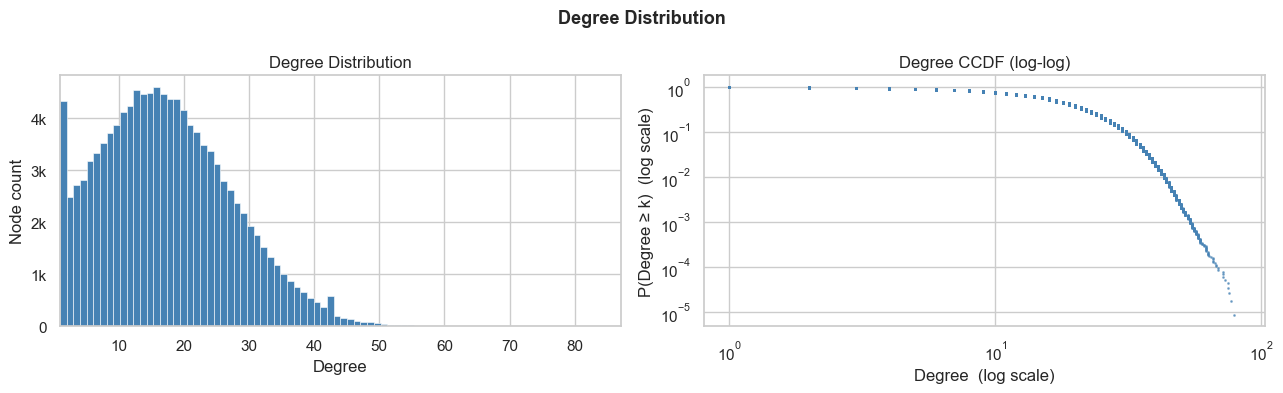

degree gini: 0.313


In [8]:
degrees = np.array([d for _, d in G.degree()])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# linear histogram
ax = axes[0]
ax.hist(degrees, bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlim(1)
ax.set_xlabel('Degree')
ax.set_ylabel('Node count')
ax.set_title('Degree Distribution')
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else str(int(x)))
)

# log-log CCDF — a straight line here indicates power-law behaviour
ax = axes[1]
sorted_deg = np.sort(degrees)
ccdf = 1.0 - np.arange(1, len(sorted_deg) + 1) / len(sorted_deg)
ax.loglog(sorted_deg, ccdf, '.', markersize=2, color='steelblue', alpha=0.6)
ax.set_xlabel('Degree  (log scale)')
ax.set_ylabel('P(Degree ≥ k)  (log scale)')
ax.set_title('Degree CCDF (log-log)')

plt.suptitle('Degree Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'degree gini: {1 - 2*np.trapz(np.cumsum(np.sort(degrees))/degrees.sum(), np.linspace(0,1,len(degrees))):.3f}')

### 2.1 deg-weight correlation

## 3. Node Attributes

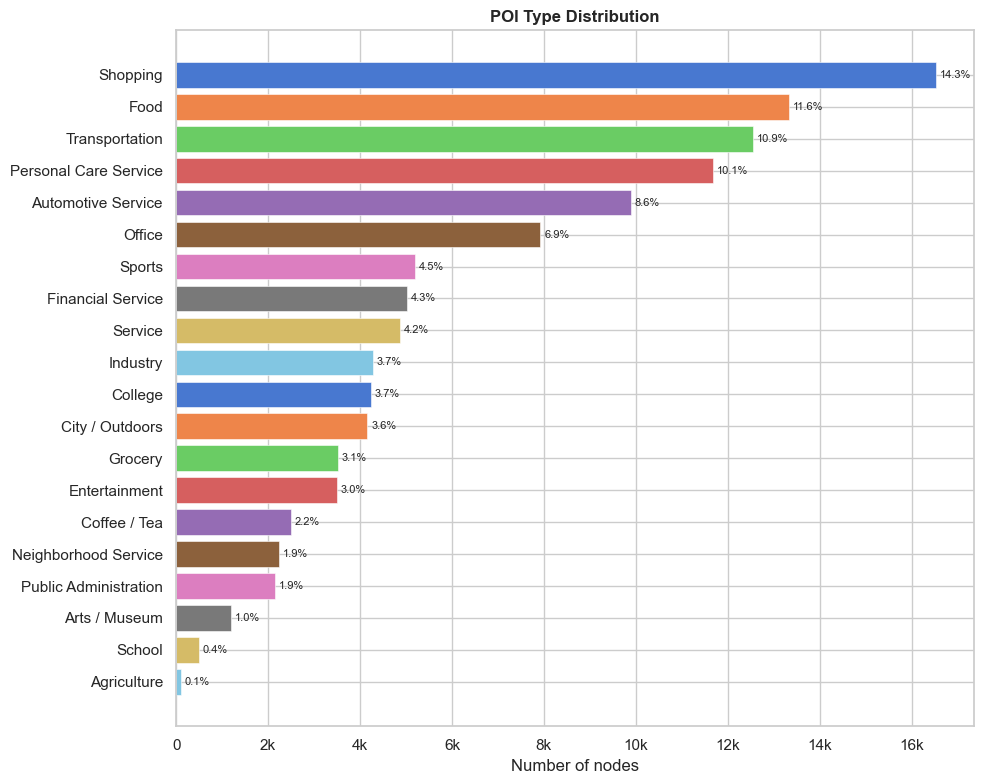

             POI Type  Count  Fraction
             Shopping  16532  0.143314
                 Food  13325  0.115513
       Transportation  12558  0.108864
Personal Care Service  11680  0.101253
   Automotive Service   9888  0.085718
               Office   7923  0.068684
               Sports   5193  0.045018
    Financial Service   5015  0.043474
              Service   4876  0.042270
             Industry   4285  0.037146
              College   4234  0.036704
      City / Outdoors   4158  0.036045
              Grocery   3526  0.030567
        Entertainment   3504  0.030376
         Coffee / Tea   2503  0.021698
 Neighborhood Service   2231  0.019340
Public Administration   2141  0.018560
        Arts / Museum   1190  0.010316
               School    489  0.004239
          Agriculture    104  0.000902


In [5]:
poi_types   = [data.get('poi_type', 'Unknown') for _, data in G.nodes(data=True)]
type_counts = Counter(poi_types)
type_df     = pd.DataFrame(type_counts.most_common(), columns=['POI Type', 'Count'])
type_df['Fraction'] = type_df['Count'] / type_df['Count'].sum()

palette = sns.color_palette('muted', len(type_df))

fig, ax = plt.subplots(figsize=(10, max(4, len(type_df) * 0.4)))
bars = ax.barh(type_df['POI Type'][::-1], type_df['Count'][::-1],
               color=palette[::-1], edgecolor='white', linewidth=0.4)
ax.set_xlabel('Number of nodes')
ax.set_title('POI Type Distribution', fontweight='bold')
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else str(int(x)))
)
for bar, frac in zip(bars, type_df['Fraction'][::-1]):
    ax.text(bar.get_width() + type_df['Count'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{frac:.1%}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(type_df.to_string(index=False))

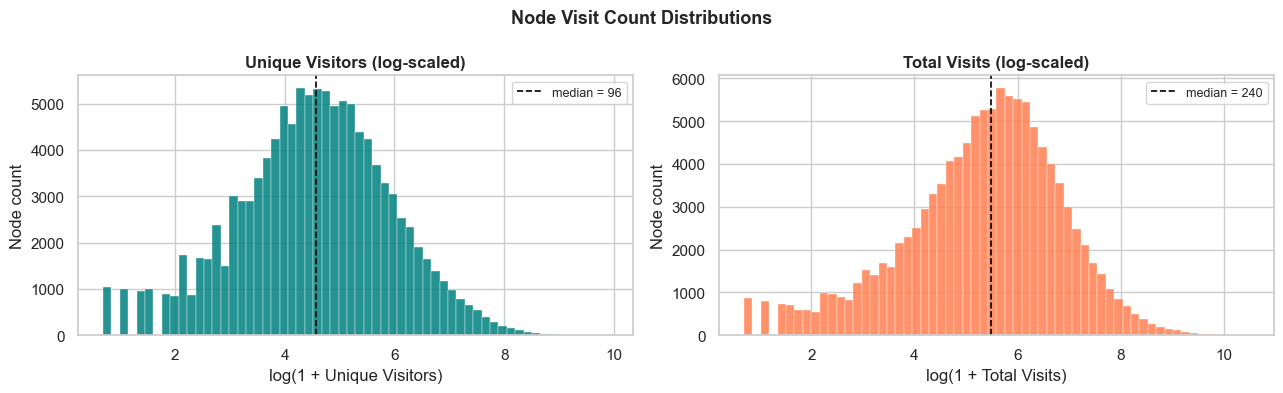

In [6]:
unique_visits = np.array([d.get('unique_visits', 0) for _, d in G.nodes(data=True)], dtype=float)
total_visits  = np.array([d.get('total_visits',  0) for _, d in G.nodes(data=True)], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, raw, label, color in [
    (axes[0], unique_visits, 'Unique Visitors', 'teal'),
    (axes[1], total_visits,  'Total Visits',    'coral'),
]:
    log_data = np.log1p(raw[raw > 0])
    ax.hist(log_data, bins=60, color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.set_xlabel(f'log(1 + {label})')
    ax.set_ylabel('Node count')
    ax.set_title(f'{label} (log-scaled)', fontweight='bold')
    med_raw = np.median(raw[raw > 0])
    ax.axvline(np.log1p(med_raw), color='black', linestyle='--', linewidth=1.2,
               label=f'median = {int(med_raw):,}')
    ax.legend(fontsize=9)

plt.suptitle('Node Visit Count Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Edge Attributes

C:\Users\User\AppData\Local\Temp\ipykernel_28488\3452317520.py:31: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28488\3452317520.py:31: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()


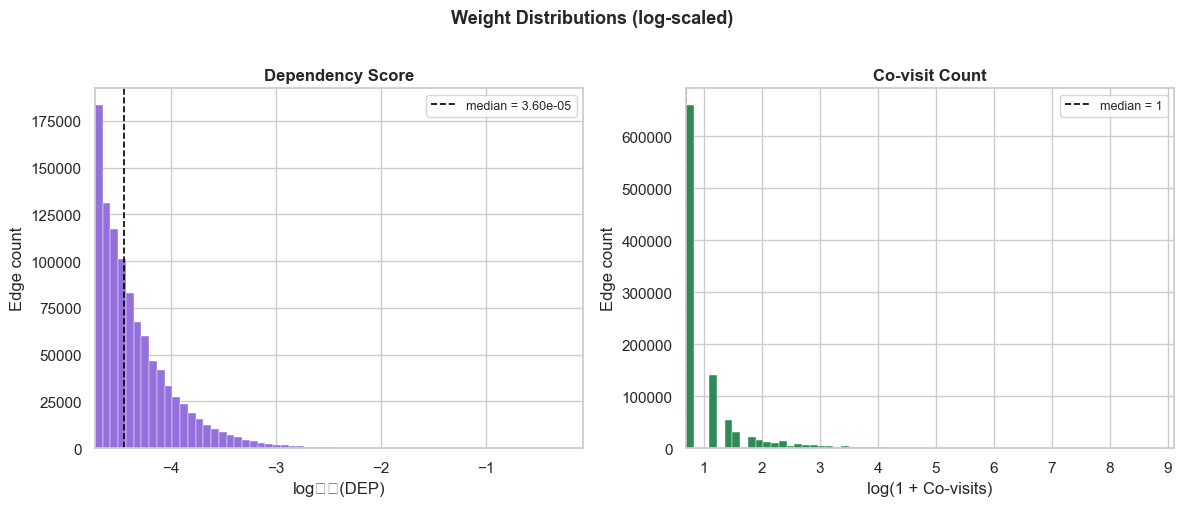

DEP     — zero-weight edges: 0  (0.0%)
DIST    — range: [0.00, 162.8] km,  median: 2.18 km
COVISIT — range: [1, 6020],  median: 1
Corr (DEP): SignificanceResult(statistic=-0.028334990500142456, pvalue=1.811259185809918e-179)
Corr (COV): SignificanceResult(statistic=-0.11187879445105199, pvalue=0.0)


In [15]:
dep_vals      = np.array(list(nx.get_edge_attributes(G, 'DEP').values()),        dtype=float)
dist_vals     = np.array(list(nx.get_edge_attributes(G, 'DIST_KM').values()),    dtype=float)
covisit_vals  = np.array(list(nx.get_edge_attributes(G, 'N_COVISITS').values()), dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DEP
ax = axes[0]
dep_pos = dep_vals[dep_vals > 0]
ax.hist(np.log10(dep_pos), bins=60, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.set_xlabel('log₁₀(DEP)')
ax.set_xlim(min(np.log10(dep_pos)))
ax.set_ylabel('Edge count')
ax.set_title('Dependency Score', fontweight='bold')
ax.axvline(np.log10(np.median(dep_pos)), color='black', linestyle='--', linewidth=1.2,
           label=f'median = {np.median(dep_pos):.2e}')
ax.legend(fontsize=9)

# Co-visits
ax = axes[1]
ax.hist(np.log1p(covisit_vals), bins=60, color='seagreen', edgecolor='white', linewidth=0.3)
ax.set_xlabel('log(1 + Co-visits)')
ax.set_xlim(min(np.log1p(covisit_vals)))
ax.set_ylabel('Edge count')
ax.set_title('Co-visit Count', fontweight='bold')
ax.axvline(np.log1p(np.median(covisit_vals)), color='black', linestyle='--', linewidth=1.2,
           label=f'median = {int(np.median(covisit_vals))}')
ax.legend(fontsize=9)

plt.suptitle('Weight Distributions (log-scaled)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'DEP     — zero-weight edges: {(dep_vals == 0).sum():,}  ({(dep_vals == 0).mean():.1%})')
print(f'DIST    — range: [{dist_vals.min():.2f}, {dist_vals.max():.1f}] km,  median: {np.median(dist_vals):.2f} km')
print(f'COVISIT — range: [{int(covisit_vals.min())}, {int(covisit_vals.max())}],  median: {int(np.median(covisit_vals))}')
print('='*50)
degrees_dict = G.degree() 
edge_degrees = np.array([
    (degrees_dict[u] * degrees_dict[v])**0.5 
    for u, v in G.edges()
])
print(f"Corr (DEP): {spearmanr(edge_degrees, dep_vals)}")
print(f"Corr (COV): {spearmanr(edge_degrees, covisit_vals)}")

## 5. Spatial Layout

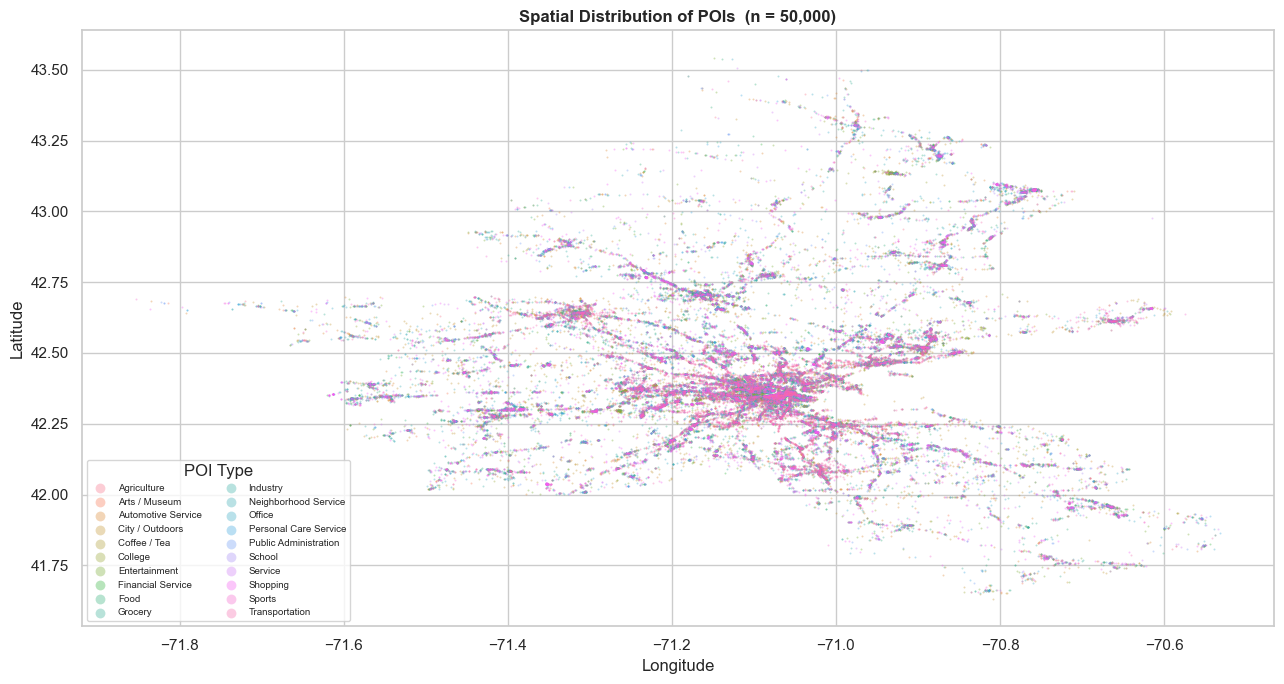

In [8]:
import random

sample_nodes = list(G.nodes())
if len(sample_nodes) > 50_000:
    random.seed(42)
    sample_nodes = random.sample(sample_nodes, 50_000)

lats  = np.array([G.nodes[n].get('latitude',  float('nan')) for n in sample_nodes])
lngs  = np.array([G.nodes[n].get('longitude', float('nan')) for n in sample_nodes])
types = np.array([G.nodes[n].get('poi_type',  'Unknown')    for n in sample_nodes])

unique_types = sorted(set(types))
type_idx     = np.array([unique_types.index(t) for t in types])
palette      = sns.color_palette('husl', len(unique_types))

fig, ax = plt.subplots(figsize=(13, 7))
for i, t in enumerate(unique_types):
    mask = type_idx == i
    ax.scatter(lngs[mask], lats[mask],
               c=[palette[i]], s=2, alpha=0.35, label=t, linewidths=0)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Spatial Distribution of POIs  (n = {len(sample_nodes):,})', fontweight='bold')
ax.legend(markerscale=5, loc='lower left', fontsize=7,
          title='POI Type', ncol=2, framealpha=0.8)
plt.tight_layout()
plt.show()

## 6. Centrality & Hub Nodes

In [9]:
# top nodes by degree
deg_cent   = dict(G.degree())
top_degree = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:20]

top_df = pd.DataFrame(top_degree, columns=['Node', 'Degree'])
top_df['POI Type']     = top_df['Node'].map(lambda n: G.nodes[n].get('poi_type',    'Unknown'))
top_df['Total Visits'] = top_df['Node'].map(lambda n: G.nodes[n].get('total_visits', 0))
top_df.index = range(1, len(top_df) + 1)

print('Top 20 Nodes by Degree:\n')
print(top_df.to_string())

# approximate betweenness — k=500 pivot nodes, O(k * E)
print('\nComputing approximate betweenness (k=500)...')
bet_cent = nx.betweenness_centrality(G, k=500, normalized=True, seed=42)
top_bet  = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

bet_df = pd.DataFrame(top_bet, columns=['Node', 'Betweenness (approx)'])
bet_df['POI Type']  = bet_df['Node'].map(lambda n: G.nodes[n].get('poi_type', 'Unknown'))
bet_df['Degree']    = bet_df['Node'].map(deg_cent)
bet_df.index = range(1, len(bet_df) + 1)

print('\nTop 10 Nodes by Approximate Betweenness Centrality:\n')
print(bet_df.to_string())

Top 20 Nodes by Degree:

                        Node  Degree               POI Type  Total Visits
1        22f-222@62j-q3b-6zf      83               Shopping           389
2        22j-222@62j-pm8-sh5      79         Transportation           284
3        22d-222@62j-q3b-6zf      77                   Food           317
4        zzw-223@62j-q3b-7bk      76                Grocery           176
5        22k-222@62j-q3b-7dv      75           Coffee / Tea           371
6        22j-222@62j-q3b-7dv      75               Shopping           319
7        23c-222@62j-q3b-7dv      73               Shopping           130
8        22h-223@62j-q3b-7dv      72          Arts / Museum           306
9        222-222@62j-sgk-fzz      72               Shopping           156
10       226-222@62j-pm8-rp9      72               Shopping           572
11       zzw-223@62j-q3b-7dv      69  Personal Care Service           178
12       228-222@62j-q3b-7bk      69        City / Outdoors           195
13       227-

Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\IPython\core\interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\User\AppData\Local\Temp\ipykernel_8936\282980551.py", line 15, in <module>
    bet_cent = nx.betweenness_centrality(G, k=500, normalized=True, seed=42)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\networkx\utils\decorators.py", line 784, in func
    return argmap._lazy_compile(__wrapper)(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<class 'networkx.utils.decorators.argmap'> compilation 54", line 4, in argmap_betweenness_centrality_50
    import inspect
            ^^^^^^^
  File "c:\Users\User\anaconda3\envs\depnet\Lib\site-packages\networkx\utils\backends.py", line 551, in _call_if_no_backends_installed
    return self.orig_func(*a

## 7. Assortativity & Mixing

Degree assortativity  : +0.2987
  (negative = hubs connect to low-degree nodes)
POI type assortativity: +0.0675
  (positive = same-type POIs tend to co-occur)


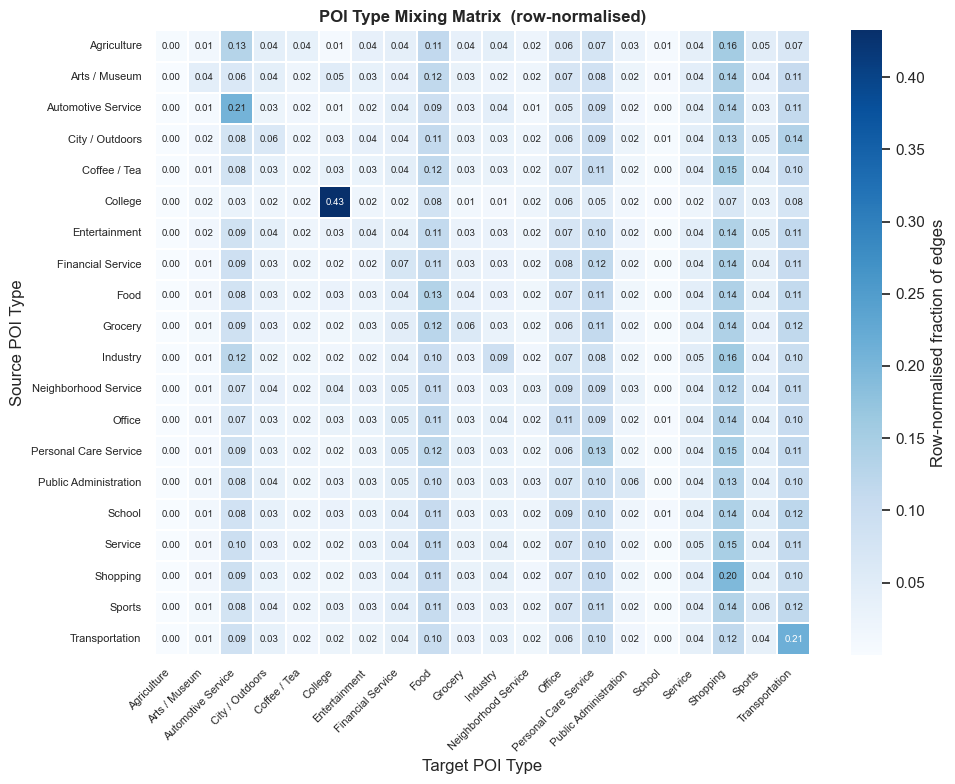

In [10]:
deg_assort = nx.degree_assortativity_coefficient(G)
poi_assort = nx.attribute_assortativity_coefficient(G, 'poi_type')

print(f'Degree assortativity  : {deg_assort:+.4f}')
print(f'  (negative = hubs connect to low-degree nodes)')
print(f'POI type assortativity: {poi_assort:+.4f}')
print(f'  (positive = same-type POIs tend to co-occur)')

# POI type mixing matrix
type_pairs = []
for u, v in G.edges():
    tu = G.nodes[u].get('poi_type', 'Unknown')
    tv = G.nodes[v].get('poi_type', 'Unknown')
    type_pairs.append((tu, tv))
    type_pairs.append((tv, tu))

pair_df  = pd.DataFrame(type_pairs, columns=['Source', 'Target'])
mixing   = pair_df.groupby(['Source', 'Target']).size().unstack(fill_value=0)
mix_norm = mixing.div(mixing.sum(axis=1), axis=0)   # row-normalised

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    mix_norm, annot=True, fmt='.2f', cmap='Blues', linewidths=0.3,
    ax=ax, annot_kws={'size': 7},
    cbar_kws={'label': 'Row-normalised fraction of edges'}
)
ax.set_title('POI Type Mixing Matrix  (row-normalised)', fontweight='bold')
ax.set_xlabel('Target POI Type')
ax.set_ylabel('Source POI Type')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.show()